# Duygu Analizi: Derin Öğrenme Yöntemleri ile Ürün Yorumlarının Sınıflandırılması

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

## Veri Kümesinin Yüklenmesi

Bu çalışmada Kaggle platformunda bulunan "IMDB Dataset of 50K Movie Reviews" veri kümesi kullanılmıştır.

Veri kümesi kagglehub kütüphanesi kullanılarak indirilmiştir.

In [48]:
import kagglehub
import os
import pandas as pd

# Veri kümesini indir
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# CSV dosyasını oku
df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))

df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Veri Kümesinin Genel İncelemesi

Bu bölümde veri kümesinin yapısı incelenmiştir. Veri kümesi her bir film yorumu ve buna karşılık gelen duygu etiketinden oluşmaktadır.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## Eksik Değer Analizi

Veri kümesinde eksik değer olup olmadığı kontrol edilmiştir.

In [50]:
df.isnull().sum()

,0
review,0
sentiment,0


## Sınıf Dağılımı

Veri kümesindeki pozitif ve negatif yorumların dağılımı incelenmiştir.

In [51]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


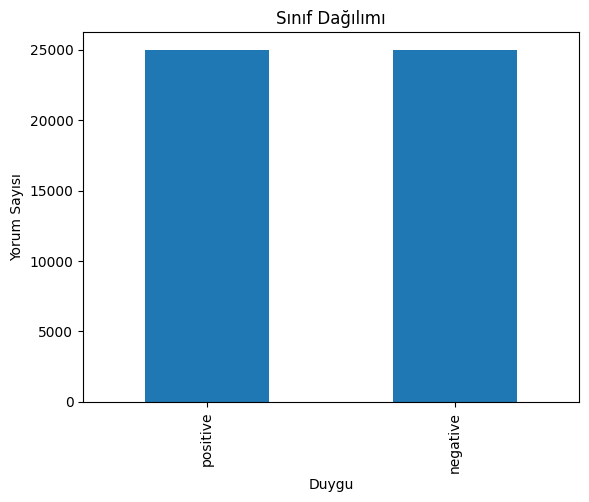

In [52]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sınıf Dağılımı")
plt.xlabel("Duygu")
plt.ylabel("Yorum Sayısı")
plt.show()

Veri kümesi dengelidir. Pozitif ve negatif yorum sayıları yaklaşık olarak eşittir.

## Yorum Uzunluklarının Analizi

Yorumların uzunlukları analiz edilmiştir.

In [53]:
df["review_length"] = df["review"].apply(len)

df["review_length"].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


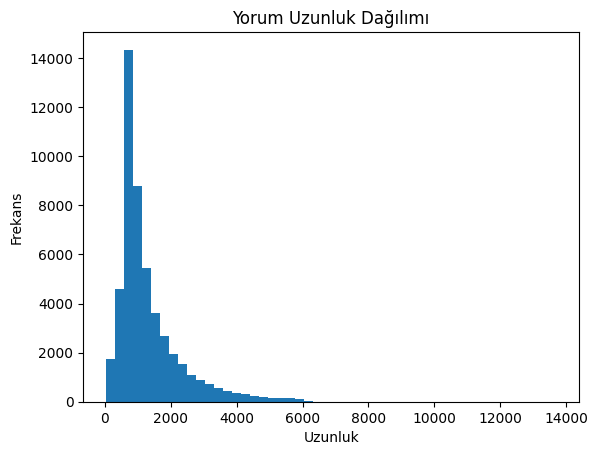

In [54]:
plt.hist(df["review_length"], bins=50)
plt.title("Yorum Uzunluk Dağılımı")
plt.xlabel("Uzunluk")
plt.ylabel("Frekans")
plt.show()

Yorum uzunlukları farklılık göstermektedir. Bazı yorumlar oldukça kısa iken bazıları daha uzun metinlerden oluşmaktadır.

In [55]:
print(df["review"][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

Yorumlar doğal dilde yazılmıştır ve model tarafından işlenebilmesi için ön işleme gerekmektedir.

## Metin Ön İşleme (Text Preprocessing)

Bu aşamada, modelin daha iyi öğrenebilmesi için metinler temizlenmiştir.

Aşağıdaki işlemler uygulanmıştır:
- Küçük harfe çevirme
- HTML etiketlerini kaldırma
- Noktalama işaretlerini kaldırma
- Gereksiz boşlukları temizleme

In [56]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)  # HTML temizleme
    text = re.sub(r"http\S+|www\S+", "", text)  # linkleri sil
    text = text.translate(str.maketrans("", "", string.punctuation))  # noktalama
    text = re.sub(r"\s+", " ", text).strip()  # boşluk temizleme
    return text

In [57]:
df["clean_review"] = df["review"].apply(clean_text)

Metinler temizlenmiş ve model için uygun hale getirilmiştir.

## Etiketlerin Sayısal Formata Dönüştürülmesi

Modelin öğrenebilmesi için duygu etiketleri sayısal değerlere dönüştürülmüştür.

In [58]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})
df.head()

,review,sentiment,review_length,clean_review,label
0,One of the other reviewers has mentioned that ...,positive,1761,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,998,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,926,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,748,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter matteis love in the time of money is a ...,1


## Veri Kümesinin Eğitim ve Test Olarak Ayrılması

Veri kümesi eğitim ve test verisi olarak ikiye ayrılmıştır.

In [59]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Baseline Model: TF-IDF + Logistic Regression

Bu aşamada derin öğrenme modelinden önce basit bir baseline model oluşturulmuştur. Baseline olarak TF-IDF özellikleri ve Lojistik Regresyon algoritması kullanılmıştır. Bu model, derin öğrenme modelinin başarısını karşılaştırmak için referans değer sağlamaktadır.

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tfidf = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.8968
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## Baseline Sonuçları

TF-IDF ve Logistic Regression kullanılarak oluşturulan baseline model değerlendirilmiştir.

Sonuçlar:

- Accuracy: %89.68
- Precision: %90
- Recall: %90
- F1-Score: %90

Bu değerler projenin referans (baseline) performansı olarak kabul edilmiştir.
Daha sonraki derin öğrenme modellerinin başarısı bu sonuçlarla karşılaştırılacaktır.

## Metinlerin Sayısal Vektörlere Dönüştürülmesi

Metinler tokenizer kullanılarak sayısal dizilere dönüştürülmüştür.

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000
oov_token = "<OOV>"

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_token
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Tüm metinlerin aynı uzunlukta olması için padding işlemi uygulanmıştır.

In [62]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

## Derin Öğrenme Modelinin Oluşturulması

Bu çalışmada metin sınıflandırması için basit bir derin öğrenme modeli oluşturulmuştur.

Model aşağıdaki katmanlardan oluşmaktadır:

- Embedding katmanı
- GlobalAveragePooling1D katmanı
- Dense katmanı
- Dropout katmanı
- Çıkış katmanı

Çıkış katmanında sigmoid aktivasyon fonksiyonu kullanılmıştır çünkü problem ikili sınıflandırma problemidir.

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_length,)),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,225 (2.46 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

## Modelin Derlenmesi

Model, binary_crossentropy kayıp fonksiyonu ve Adam optimizer kullanılarak derlenmiştir.

Binary_crossentropy, iki sınıflı sınıflandırma problemleri için uygundur.

In [64]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

## Modelin Eğitilmesi

Model eğitim verisi üzerinde eğitilmiştir. Eğitim sırasında doğrulama verisi kullanılarak modelin performansı takip edilmiştir.

In [65]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7656 - loss: 0.4815 - val_accuracy: 0.8580 - val_loss: 0.3358
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8770 - loss: 0.2991 - val_accuracy: 0.8744 - val_loss: 0.3019
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8981 - loss: 0.2563 - val_accuracy: 0.8758 - val_loss: 0.3011
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9110 - loss: 0.2281 - val_accuracy: 0.8544 - val_loss: 0.3471
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9210 - loss: 0.2095 - val_accuracy: 0.8711 - val_loss: 0.3252


## Eğitim Sonuçlarının Görselleştirilmesi

Eğitim sürecinde accuracy ve loss değerleri görselleştirilmiştir.

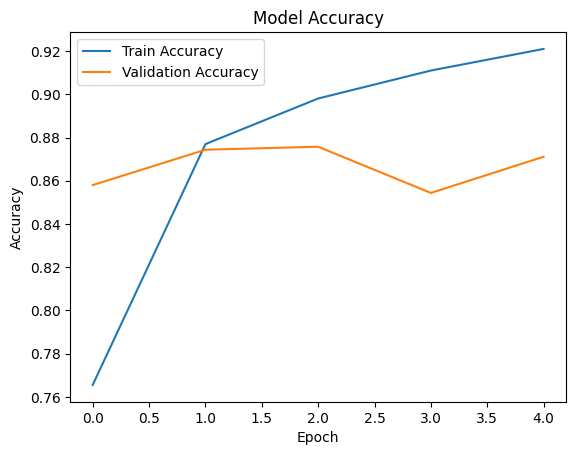

In [66]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

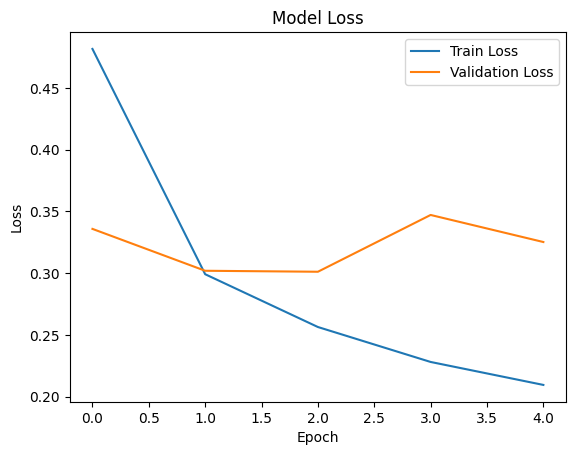

In [67]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Grafiklere göre model eğitim verisi üzerinde başarılı bir şekilde öğrenmiştir. Eğitim doğruluğu epoch sayısı arttıkça yükselmiş ve eğitim kaybı azalmıştır.

Ancak doğrulama kaybı ikinci epoch sonrasında artmaya başlamıştır. Bu durum modelde hafif bir aşırı öğrenme (overfitting) olduğunu göstermektedir.

Validation accuracy yaklaşık %87 seviyesinde kalmıştır. Bu sonuç, modelin genel olarak başarılı olduğunu ancak daha iyi genelleme için epoch sayısının azaltılabileceğini veya regularization yöntemlerinin kullanılabileceğini göstermektedir.

## Test Verisi Üzerinde Model Performansı

Modelin gerçek performansını görmek için test verisi üzerinde değerlendirme yapılmıştır.

In [68]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8659 - loss: 0.3303
Test Loss: 0.33025074005126953
Test Accuracy: 0.8658999800682068


## Sınıflandırma Raporu

In [69]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      5000
           1       0.86      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## Karışıklık Matrisi

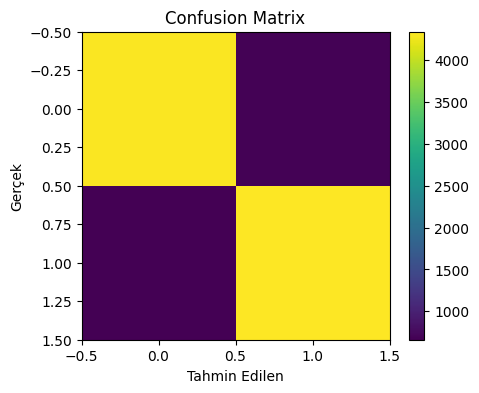

[[4319  681]
 [ 660 4340]]


In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")

plt.colorbar()

plt.show()

print(cm)

## Model Performansının Değerlendirilmesi

Model test verisi üzerinde yaklaşık %86.7 doğruluk elde etmiştir.

Bu sonuç, modelin yeni ve daha önce görmediği veriler üzerinde de başarılı tahminler yapabildiğini göstermektedir.

Eğitim ve doğrulama sonuçları ile test sonuçlarının birbirine yakın olması, modelin aşırı öğrenme (overfitting) probleminin düşük seviyede olduğunu göstermektedir.

Genel olarak model başarılı bir performans sergilemiştir.

## Sonuç

Bu projede IMDB film yorumları veri kümesi kullanılarak duygu analizi yapılmıştır.

Veri ön işleme adımları uygulanmış, metinler sayısal verilere dönüştürülmüş ve bir derin öğrenme modeli oluşturulmuştur.

Model yaklaşık %87 doğruluk oranı ile başarılı sonuçlar vermiştir.

Gelecekte model performansını artırmak için daha gelişmiş modeller (LSTM, BERT vb.) kullanılabilir.

## Literatür Özeti

Son yıllarda duygu analizi (sentiment analysis) alanında derin öğrenme yöntemleri активно kullanılmaktadır.

2021 sonrası yapılan çalışmalarda özellikle aşağıdaki modeller öne çıkmaktadır:

- LSTM (Long Short-Term Memory): Uzun metinlerde bağlamı daha iyi yakalayabildiği için sıklıkla tercih edilmektedir.
- GRU (Gated Recurrent Unit): LSTM'e benzer şekilde çalışır ancak daha hızlıdır ve daha az parametre içerir.
- BERT (Bidirectional Encoder Representations from Transformers): Metinleri iki yönlü analiz ederek daha yüksek doğruluk elde edebilmektedir.

Bu modellerin kullanıldığı birçok çalışmada, geleneksel makine öğrenmesi yöntemlerine göre daha yüksek başarı oranları elde edilmiştir.

Ayrıca, Google Scholar verilerine göre 2021 sonrası "sentiment analysis" ve "deep learning" anahtar kelimeleri ile yapılan binlerce akademik yayın bulunmaktadır. Bu durum, konunun güncel ve aktif olarak olduğunu göstermektedir.

Bu projede ise daha basit bir derin öğrenme modeli kullanılarak duygu analizi problemi çözülmüş ve temel yaklaşım gösterilmiştir.